# Eixo 5 – Validação, Interpretabilidade e Robustez (Múltiplos Modelos)

Este notebook complementa as modelagens do Eixo 3, adicionando para **Regressão Logística, Random Forest e LightGBM**:
- Importância de variáveis (Permutation e, para árvores, SHAP)
- Generalização via validação cruzada
- Análise de fairness (equidade entre grupos)

Partimos do pré-processamento e dos splits já definidos no notebook original.

In [1]:
# Importações e preparação dos dados (igual ao notebook original)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
import shap

# Configuração de estilo para gráficos
sns.set_style("whitegrid")
sns.set_palette("Blues")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Função de limpeza
def limpar_nomes(df):
    df.columns = [re.sub(r'[^\w\s]', '_', col).replace(' ', '_') for col in df.columns]
    return df

df = pd.read_csv('dados_arrumados.csv')
df = limpar_nomes(df)

target = 'HadHeartAttack'
features_criadas = ['ComorbidityCount', 'HighRiskLifestyle']

# Usaremos o cenário híbrido (todas as variáveis)
X = df.drop(columns=[target])
y = df[target]

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# UnderSampling (aplicado dentro do pipeline para validação cruzada, mas também para treino final)
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# Escalonamento para Regressão Logística
scaler = MinMaxScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

# Treinar cada modelo (usando dados escalados para LR)
trained_models = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_res_scaled, y_train_res)
        trained_models[name] = model
    else:
        model.fit(X_train_res, y_train_res)
        trained_models[name] = model

print("Dados carregados e modelos treinados com under-sampling.")
print(f"Dimensão de X: {X.shape}")

/home/gabriel/Documentos/ESTUDOS/7_semestre/PCD/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dados carregados e modelos treinados com under-sampling.
Dimensão de X: (358478, 55)


## 1. Importância de Variáveis

### 1.1 Permutation Importance (para todos os modelos)
Mede a perda de desempenho (AUC) quando cada variável é embaralhada.

/tmp/ipykernel_19816/2233057266.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='Blues_d')


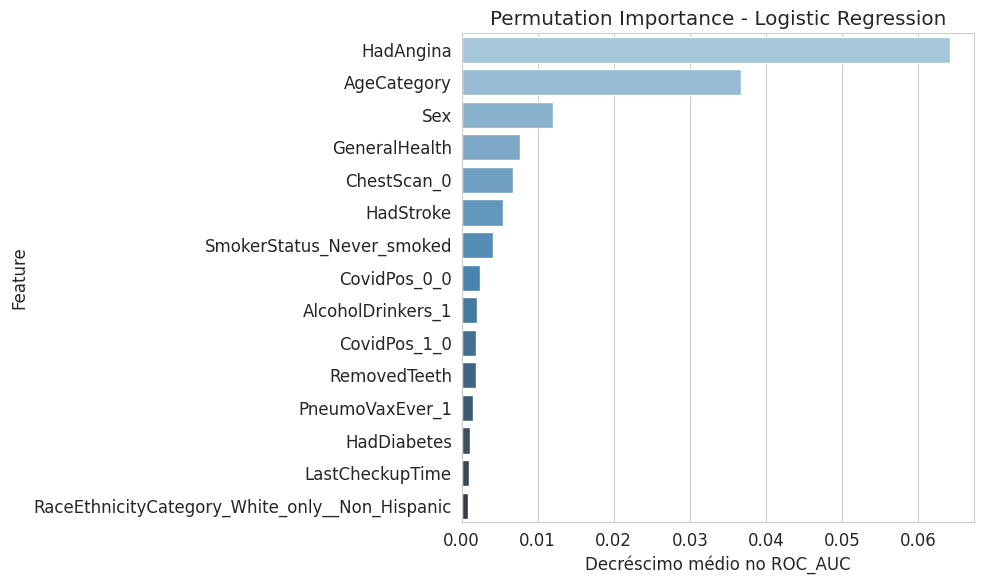

/tmp/ipykernel_19816/2233057266.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='Blues_d')


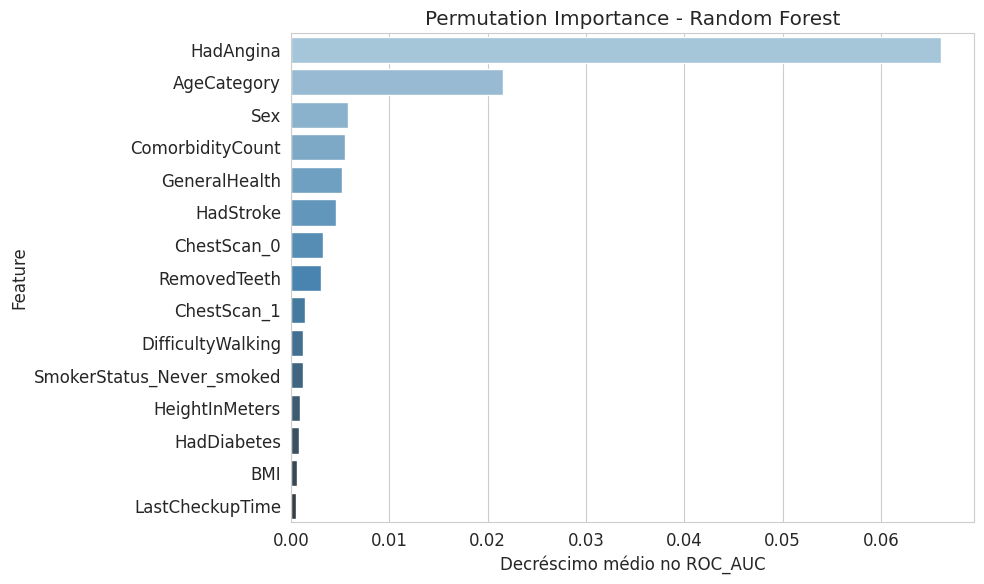

/tmp/ipykernel_19816/2233057266.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='Blues_d')


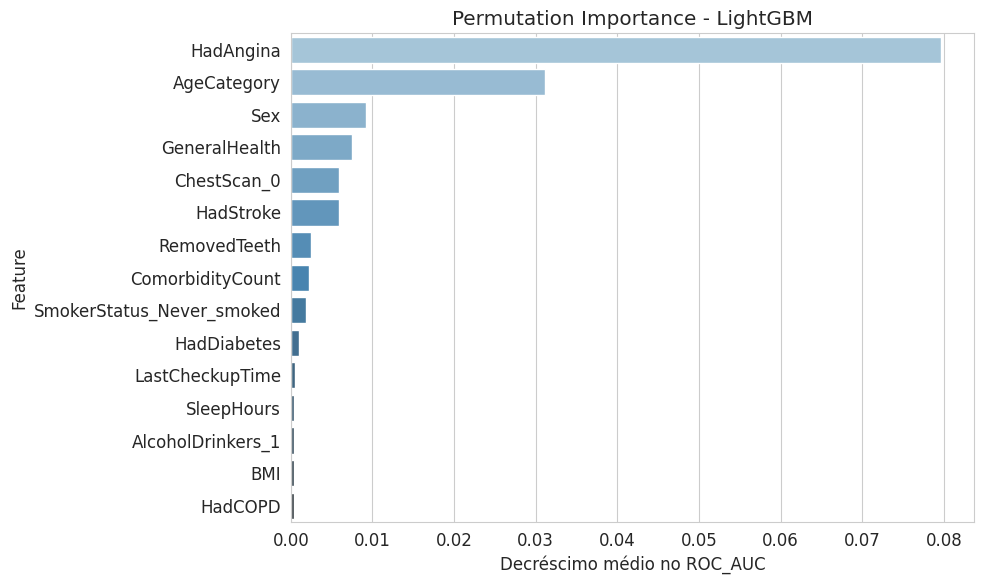

In [2]:
def plot_permutation_importance(model, X_val, y_val, feature_names, model_name, metric='roc_auc', n_repeats=10):
    result = permutation_importance(model, X_val, y_val, n_repeats=n_repeats,
                                    scoring=metric, random_state=42, n_jobs=-1)
    sorted_idx = result.importances_mean.argsort()[::-1]
    
    # Criar DataFrame para facilitar a plotagem
    imp_df = pd.DataFrame({
        'Feature': [feature_names[i] for i in sorted_idx[:15]],
        'Importance': result.importances_mean[sorted_idx[:15]],
        'Std': result.importances_std[sorted_idx[:15]]
    })
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette='Blues_d')
    plt.xlabel(f'Decréscimo médio no {metric.upper()}')
    plt.title(f'Permutation Importance - {model_name}')
    plt.tight_layout()
    plt.show()

# Para LR, usar X_test_scaled; para os outros, X_test
plot_permutation_importance(trained_models['Logistic Regression'], X_test_scaled, y_test, X.columns, 'Logistic Regression')
plot_permutation_importance(trained_models['Random Forest'], X_test, y_test, X.columns, 'Random Forest')
plot_permutation_importance(trained_models['LightGBM'], X_test, y_test, X.columns, 'LightGBM')

### 1.2 Razão de Chances (Odds Ratio) para Regressão Logística

A razão de chances (odds ratio) é uma medida interpretável que indica como cada variável afeta a chance de ocorrência do evento (ter ataque cardíaco). Valores > 1 indicam aumento da chance, valores < 1 indicam redução.

/tmp/ipykernel_19816/2758867290.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_odds, x='Odds_Ratio', y='Feature', palette='Blues_d')


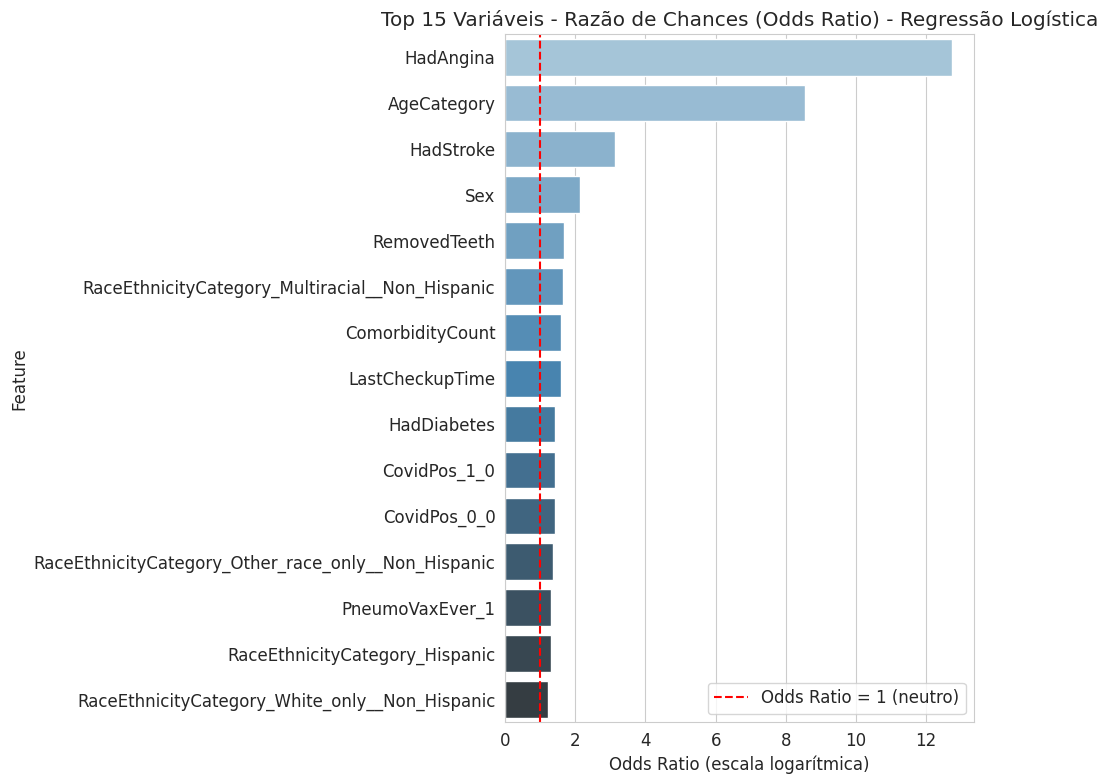

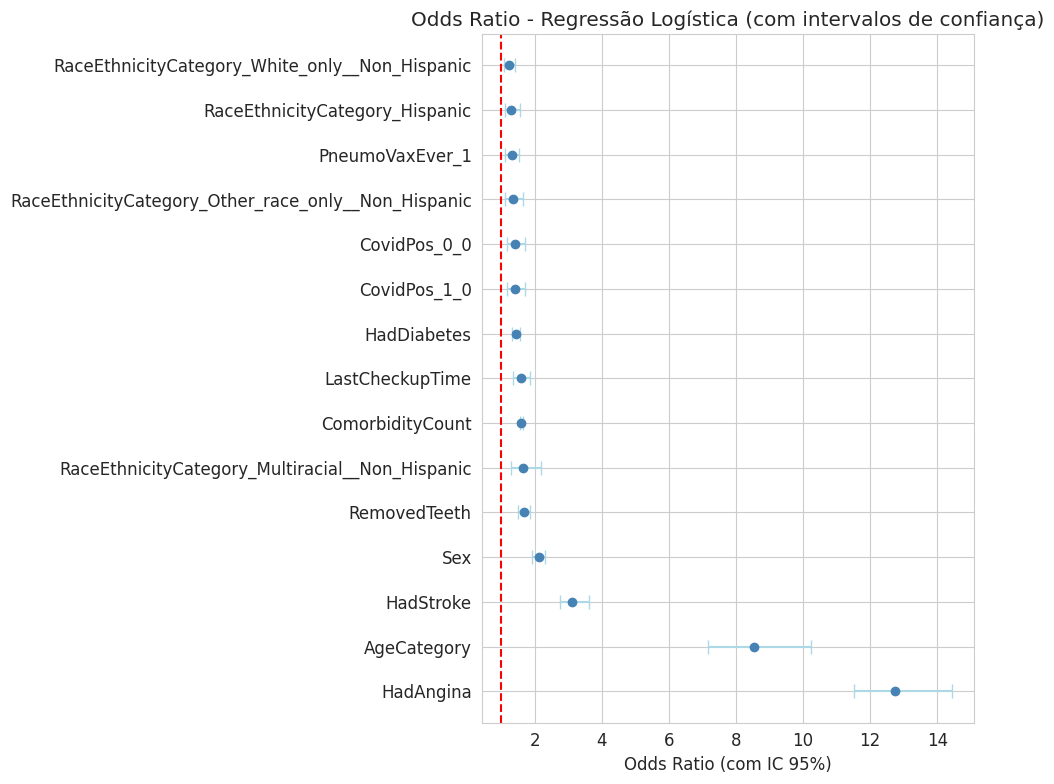

In [3]:
# Obter coeficientes e calcular odds ratio
coef = trained_models['Logistic Regression'].coef_[0]
odds_ratio = np.exp(coef)

# Calcular intervalos de confiança bootstrap para os odds ratios
n_bootstrap = 1000
coef_bootstrap = []
for _ in range(n_bootstrap):
    # Amostragem bootstrap dos dados de treino escalados
    idx = np.random.choice(len(X_train_res_scaled), len(X_train_res_scaled), replace=True)
    X_boot = X_train_res_scaled[idx]
    y_boot = y_train_res.iloc[idx] if hasattr(y_train_res, 'iloc') else y_train_res[idx]
    lr_boot = LogisticRegression(max_iter=1000, random_state=42)
    lr_boot.fit(X_boot, y_boot)
    coef_bootstrap.append(lr_boot.coef_[0])

coef_bootstrap = np.array(coef_bootstrap)
ci_lower = np.exp(np.percentile(coef_bootstrap, 2.5, axis=0))
ci_upper = np.exp(np.percentile(coef_bootstrap, 97.5, axis=0))

# Criar DataFrame com odds ratios e intervalos
odds_df = pd.DataFrame({
    'Feature': X.columns,
    'Odds_Ratio': odds_ratio,
    'CI_lower': ci_lower,
    'CI_upper': ci_upper
}).sort_values('Odds_Ratio', ascending=False)

# Plotar top 15 odds ratios
plt.figure(figsize=(10, 8))
top_odds = odds_df.head(15)
sns.barplot(data=top_odds, x='Odds_Ratio', y='Feature', palette='Blues_d')
plt.axvline(x=1, color='red', linestyle='--', label='Odds Ratio = 1 (neutro)')
plt.xlabel('Odds Ratio (escala logarítmica)')
plt.title('Top 15 Variáveis - Razão de Chances (Odds Ratio) - Regressão Logística')
plt.legend()
plt.tight_layout()
plt.show()

# Opcional: gráfico de floresta para variáveis mais importantes
plt.figure(figsize=(10, 8))
top_odds = odds_df.head(15)
y_pos = np.arange(len(top_odds))
plt.errorbar(top_odds['Odds_Ratio'], y_pos, 
             xerr=[top_odds['Odds_Ratio'] - top_odds['CI_lower'], top_odds['CI_upper'] - top_odds['Odds_Ratio']],
             fmt='o', capsize=5, color='steelblue', ecolor='lightblue')
plt.axvline(x=1, color='red', linestyle='--')
plt.yticks(y_pos, top_odds['Feature'])
plt.xlabel('Odds Ratio (com IC 95%)')
plt.title('Odds Ratio - Regressão Logística (com intervalos de confiança)')
plt.tight_layout()
plt.show()

### 1.3 SHAP (apenas para modelos baseados em árvores)
SHAP mostra a direção do impacto de cada variável (positivo ou negativo).

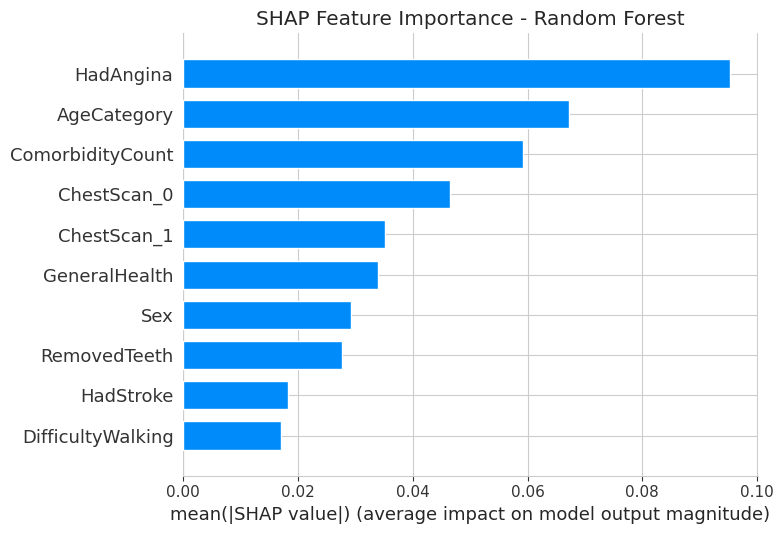

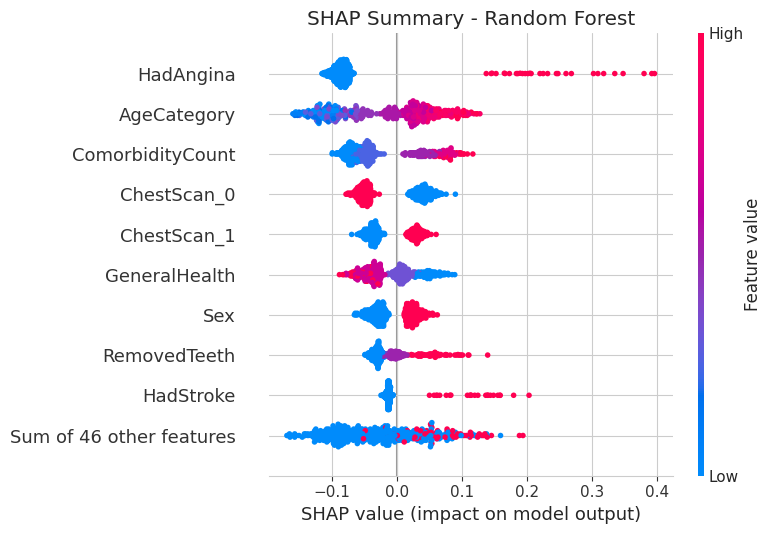

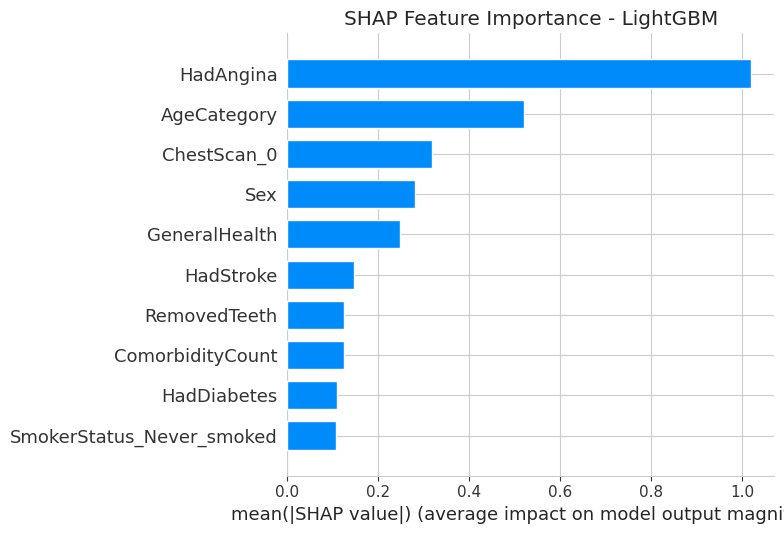

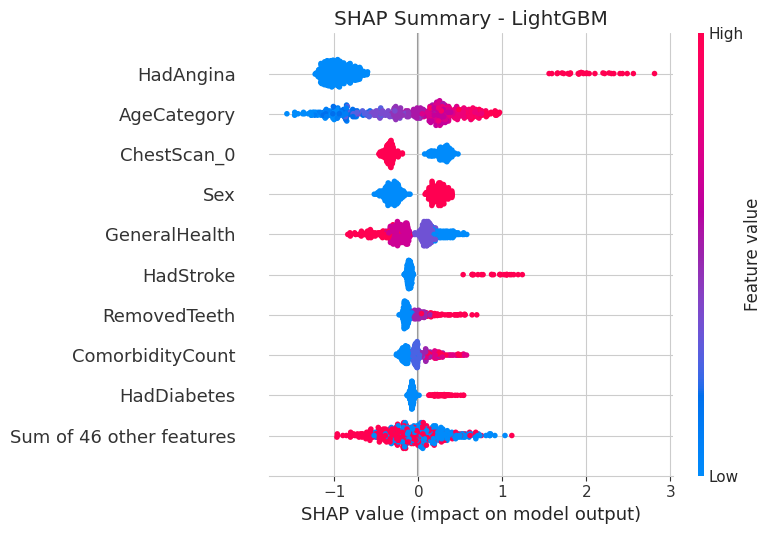

In [5]:
import matplotlib.pyplot as plt
import shap
import numpy as np # Importe o numpy para lidar com os arrays

for name in ['Random Forest', 'LightGBM']:
    model = trained_models[name]
    explainer = shap.TreeExplainer(model)
    
    X_sample = X_test.sample(min(500, len(X_test)), random_state=42)
    
    # Usa a API moderna (retorna um objeto Explanation)
    shap_explanation = explainer(X_sample)
    
    # Isola a classe positiva se o modelo for de classificação binária
    if len(shap_explanation.shape) == 3:
        # Para Random Forest (normalmente 3D): selecionamos a classe 1
        shap_explanation_2d = shap_explanation[:, :, 1]
    else:
        # Para LightGBM (normalmente 2D): já é a saída
        shap_explanation_2d = shap_explanation
    
    # Gráfico de barras (importância global) limitando estritamente a 10
    # USANDO A API LEGADA (summary_plot com plot_type="bar") PARA EVITAR A BARRA "OTHER"
    plt.figure()
    
    # Passo 1: Extrair a matriz de valores SHAP (numpy array) do objeto de explicação
    shap_values_np = shap_explanation_2d.values
    
    # Passo 2: Calcular a média do valor absoluto (mean(|SHAP|))
    # Para summary_plot, passamos a matriz raw e a função faz o cálculo
    # Mas precisamos das feature names. Vamos extrair do X_sample para garantir.
    feature_names = X_sample.columns

    # Passo 3: Criar o gráfico
    shap.summary_plot(
        shap_values_np, 
        X_sample, 
        feature_names=feature_names, 
        plot_type="bar", 
        max_display=10, 
        show=False
    )
    
    plt.title(f'SHAP Feature Importance - {name}')
    plt.tight_layout()
    plt.show()
    
    # Gráfico beeswarm (direção do impacto) limitando a 10 - MANTÉM O MODERNO
    plt.figure()
    # O beeswarm moderno (shap.plots.beeswarm) é superior
    # E ele NÃO cria a barra "Other" por padrão com max_display.
    shap.plots.beeswarm(shap_explanation_2d, max_display=10, show=False)
    plt.title(f'SHAP Summary - {name}')
    plt.tight_layout()
    plt.show()

## 2. Avaliação de Generalização com Validação Cruzada

Utilizamos validação cruzada 5‑fold com under‑sampling interno para obter estimativas mais robustas para cada modelo.

In [5]:
# Definir pipelines para cada modelo
pipelines = {
    'Logistic Regression': ImbPipeline([
        ('sampler', RandomUnderSampler(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': ImbPipeline([
        ('sampler', RandomUnderSampler(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42))
    ]),
    'LightGBM': ImbPipeline([
        ('sampler', RandomUnderSampler(random_state=42)),
        ('model', lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, pipeline in pipelines.items():
    scores_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    scores_recall = cross_val_score(pipeline, X, y, cv=cv, scoring='recall', n_jobs=-1)
    results[name] = {'AUC_mean': scores_auc.mean(), 'AUC_std': scores_auc.std(),
                     'Recall_mean': scores_recall.mean(), 'Recall_std': scores_recall.std()}
    print(f"\n{name}:")
    print(f"  AUC médio (5-fold): {scores_auc.mean():.4f} (+/- {scores_auc.std():.4f})")
    print(f"  Recall médio (5-fold): {scores_recall.mean():.4f} (+/- {scores_recall.std():.4f})")

# Comparação com o teste único (usando under-sampling nos dados de treino)
print("\n--- Desempenho no teste único (após under-sampling) ---")
for name, model in trained_models.items():
    if name == 'Logistic Regression':
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    print(f"{name:20s} AUC: {auc:.4f}")


Logistic Regression:
  AUC médio (5-fold): 0.8907 (+/- 0.0031)
  Recall médio (5-fold): 0.7741 (+/- 0.0070)

Random Forest:
  AUC médio (5-fold): 0.8864 (+/- 0.0030)
  Recall médio (5-fold): 0.7970 (+/- 0.0066)

LightGBM:
  AUC médio (5-fold): 0.8907 (+/- 0.0029)
  Recall médio (5-fold): 0.7994 (+/- 0.0052)

--- Desempenho no teste único (após under-sampling) ---
Logistic Regression  AUC: 0.8896
Random Forest        AUC: 0.8857
LightGBM             AUC: 0.8886


## 3. Análise de Fairness e Possíveis Vieses

Verificamos se cada modelo se comporta de forma equânime entre diferentes grupos demográficos. Exemplo com a variável `Sex` (ajuste conforme seu dataset).

In [2]:
# Identificar uma variável sensível (exemplo: Sex, se existir)
sensitive_col = None
for col in X.columns:
    if 'sex' in col.lower() or 'gender' in col.lower():
        sensitive_col = col
        break

if sensitive_col is None:
    print("Aviso: Nenhuma variável sensível (sexo/gênero) encontrada. Usando 'HadAngina' como demonstração.")
    sensitive_col = 'HadAngina'

def fairness_metrics(model, X, y, sensitive_col, model_name, feature_names=None):
    # Converter y para numpy e garantir alinhamento
    y_np = y.values if hasattr(y, 'values') else np.array(y)
    
    # Se X for array, converter para DataFrame
    if isinstance(X, np.ndarray):
        if feature_names is None:
            raise ValueError("Para arrays, forneça feature_names")
        X_df = pd.DataFrame(X, columns=feature_names)
    else:
        X_df = X.copy()
    
    # Resetar índices para alinhar com y_np (assumindo mesma ordem)
    X_df = X_df.reset_index(drop=True)
    y_np = y_np.reshape(-1)  # Garantir 1D
    
    groups = X_df[sensitive_col].unique()
    results = {}
    y_pred = model.predict(X_df)
    
    for group in groups:
        mask = (X_df[sensitive_col] == group).values
        y_g = y_np[mask]
        y_pred_g = y_pred[mask]
        
        if len(np.unique(y_g)) < 2 or len(np.unique(y_pred_g)) < 2:
            tn = fp = fn = tp = 0
            if (y_g == 1).sum() > 0 and (y_pred_g == 1).sum() > 0:
                tp = (y_g & y_pred_g).sum()
                fn = (y_g & ~y_pred_g).sum()
                fp = (~y_g & y_pred_g).sum()
                tn = (~y_g & ~y_pred_g).sum()
        else:
            tn, fp, fn, tp = confusion_matrix(y_g, y_pred_g).ravel()
        
        tpr = tp / (tp + fn) if (tp+fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp+tn) > 0 else 0
        precision = tp / (tp + fp) if (tp+fp) > 0 else 0
        results[group] = {'TPR': tpr, 'FPR': fpr, 'Precision': precision}
    
    df_res = pd.DataFrame(results).T
    print(f"\n{model_name} - Fairness para {sensitive_col}:")
    print(df_res)
    tpr_values = df_res['TPR'].values
    max_disparity = tpr_values.max() - tpr_values.min()
    ratio = tpr_values.min() / tpr_values.max() if tpr_values.max() > 0 else 0
    print(f"  Disparidade máxima de TPR: {max_disparity:.3f}")
    print(f"  Razão (min/max) de TPR: {ratio:.3f}")

# Avaliar fairness para cada modelo
print("\n=== Avaliação de Fairness ===\n")
fairness_metrics(trained_models['Logistic Regression'], X_test_scaled, y_test, sensitive_col, 'Logistic Regression', feature_names=X.columns)
fairness_metrics(trained_models['Random Forest'], X_test, y_test, sensitive_col, 'Random Forest')
fairness_metrics(trained_models['LightGBM'], X_test, y_test, sensitive_col, 'LightGBM')


=== Avaliação de Fairness ===


Logistic Regression - Fairness para Sex:
          TPR       FPR  Precision
0.0  0.685835  0.119851   0.181672
1.0  0.821388  0.213864   0.222611
  Disparidade máxima de TPR: 0.136
  Razão (min/max) de TPR: 0.835


/home/gabriel/Documentos/ESTUDOS/7_semestre/PCD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



Random Forest - Fairness para Sex:
        TPR       FPR  Precision
0  0.731183  0.158774   0.151580
1  0.838303  0.238682   0.207523
  Disparidade máxima de TPR: 0.107
  Razão (min/max) de TPR: 0.872

LightGBM - Fairness para Sex:
        TPR       FPR  Precision
0  0.709677  0.136374   0.167976
1  0.838589  0.244004   0.203975
  Disparidade máxima de TPR: 0.129
  Razão (min/max) de TPR: 0.846


In [4]:
# Analisar fairness para a variável 'AgeCategory' (0 a 9)
print("\n=== Fairness por Idade ===\n")

fairness_metrics(trained_models['Logistic Regression'], 
                 X_test, y_test, 'AgeCategory', 
                 'Logistic Regression (Idade)')

fairness_metrics(trained_models['Random Forest'], 
                 X_test, y_test, 'AgeCategory', 
                 'Random Forest (Idade)')

fairness_metrics(trained_models['LightGBM'], 
                 X_test, y_test, 'AgeCategory', 
                 'LightGBM (Idade)')


=== Fairness por Idade ===


Logistic Regression (Idade) - Fairness para AgeCategory:
         TPR       FPR  Precision
8   0.006250  0.003758   0.093023
2   0.000000  0.000000   0.000000
7   0.000000  0.003552   0.000000
12  0.011080  0.009450   0.153846
6   0.010067  0.002551   0.130435
5   0.000000  0.001028   0.000000
0   0.000000  0.000000   0.000000
9   0.005663  0.004969   0.076923
11  0.002347  0.006256   0.044444
10  0.009174  0.007976   0.103448
3   0.012821  0.000000   1.000000
1   0.000000  0.000000   0.000000
4   0.000000  0.000821   0.000000
  Disparidade máxima de TPR: 0.013
  Razão (min/max) de TPR: 0.000


/home/gabriel/Documentos/ESTUDOS/7_semestre/PCD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



Random Forest (Idade) - Fairness para AgeCategory:
         TPR       FPR  Precision
8   0.790625  0.227382   0.176553
2   0.217391  0.016922   0.045455
7   0.732906  0.167755   0.189817
12  0.882733  0.562572   0.195701
6   0.651007  0.104095   0.192079
5   0.617143  0.074041   0.176471
0   0.277778  0.004917   0.135135
9   0.798414  0.273540   0.175898
11  0.874413  0.466172   0.188655
10  0.838940  0.380612   0.181078
3   0.474359  0.021392   0.197861
1   0.354839  0.008307   0.196429
4   0.515464  0.039114   0.148810
  Disparidade máxima de TPR: 0.665
  Razão (min/max) de TPR: 0.246

LightGBM (Idade) - Fairness para AgeCategory:
         TPR       FPR  Precision
8   0.773438  0.217073   0.180131
2   0.260870  0.016116   0.056604
7   0.737179  0.155609   0.202584
12  0.894737  0.578179   0.193529
6   0.654362  0.100013   0.199183
5   0.588571  0.064346   0.190388
0   0.277778  0.004456   0.147059
9   0.770102  0.237847   0.191441
11  0.868545  0.439692   0.196704
10  0.827727  0.36

In [3]:
# 1. Definir explicitamente a variável alvo para a análise de subgrupos
sensitive_col_angina = 'HadAngina'

print(f"\n=== Avaliação de Equidade/Desempenho por Subgrupo: {sensitive_col_angina} ===\n")

# 2. Executar a métrica para a Regressão Logística (lembrando de usar o X_test_scaled)
fairness_metrics(
    trained_models['Logistic Regression'], 
    X_test_scaled, 
    y_test, 
    sensitive_col_angina, 
    'Logistic Regression', 
    feature_names=X.columns
)

# 3. Executar a métrica para o Random Forest
fairness_metrics(
    trained_models['Random Forest'], 
    X_test, 
    y_test, 
    sensitive_col_angina, 
    'Random Forest'
)

# 4. Executar a métrica para o LightGBM
fairness_metrics(
    trained_models['LightGBM'], 
    X_test, 
    y_test, 
    sensitive_col_angina, 
    'LightGBM'
)


=== Avaliação de Equidade/Desempenho por Subgrupo: HadAngina ===


Logistic Regression - Fairness para HadAngina:
          TPR       FPR  Precision
0.0  0.538956  0.133458   0.102991
1.0  0.998233  0.992865   0.448041
  Disparidade máxima de TPR: 0.459
  Razão (min/max) de TPR: 0.540


/home/gabriel/Documentos/ESTUDOS/7_semestre/PCD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



Random Forest - Fairness para HadAngina:
        TPR       FPR  Precision
0  0.592924  0.166807   0.091784
1  1.000000  0.000000   0.446708
  Disparidade máxima de TPR: 0.407
  Razão (min/max) de TPR: 0.593

LightGBM - Fairness para HadAngina:
        TPR       FPR  Precision
0  0.576841  0.156819   0.094679
1  1.000000  0.999144   0.446919
  Disparidade máxima de TPR: 0.423
  Razão (min/max) de TPR: 0.577
